Add 5 new features (RSI, Ichimoku 65, PSAR, Bolliger Bands (high, low))

In [2]:
%pip install pandas numpy matplotlib scikit-learn tensorflow ipython

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display


In [4]:
# ==========================================
# 1. KHỞI TẠO HÀM VÀ DANH SÁCH MÃ
# ==========================================
# Hàm tính Parabolic SAR
def calculate_sar(high_col, low_col, close_col, af_start=0.02, af_step=0.02, af_max=0.2):
    sar = np.zeros(len(close_col))
    ep = np.zeros(len(close_col))
    af = np.zeros(len(close_col))
    trend = np.zeros(len(close_col))
    
    sar[0], ep[0], af[0], trend[0] = low_col[0], high_col[0], af_start, 1 
    
    for i in range(1, len(close_col)):
        sar[i] = sar[i-1] + af[i-1] * (ep[i-1] - sar[i-1])
        if trend[i-1] == 1: 
            if sar[i] > low_col[i] or sar[i] > low_col[i-1]:
                trend[i], sar[i], ep[i], af[i] = -1, ep[i-1], low_col[i], af_start
            else:
                trend[i] = 1
                ep[i] = max(ep[i-1], high_col[i])
                af[i] = min(af_max, af[i-1] + af_step) if ep[i] > ep[i-1] else af[i-1]
        else: 
            if sar[i] < high_col[i] or sar[i] < high_col[i-1]:
                trend[i], sar[i], ep[i], af[i] = 1, ep[i-1], high_col[i], af_start
            else:
                trend[i] = -1
                ep[i] = min(ep[i-1], low_col[i])
                af[i] = min(af_max, af[i-1] + af_step) if ep[i] < ep[i-1] else af[i-1]
    return sar

# Danh sách 30 mã VN30 (Dựa trên tên file bạn đã upload)
tickers = [
    'ACB', 'BCM', 'BID', 'BVH', 'CTG', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 
    'MBB', 'MSN', 'MWG', 'PLX', 'POW', 'SAB', 'SHB', 'SSB', 'SSI', 'STB', 
    'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE'
]

# Thư mục chứa dữ liệu
data_folder = 'VN30_Raw_Data'

# List để lưu kết quả đánh giá của 30 mã
results_list = []

print(f"Bắt đầu quy trình huấn luyện cho {len(tickers)} mã VN30...\n")
print("-" * 60)

Bắt đầu quy trình huấn luyện cho 30 mã VN30...

------------------------------------------------------------


Đang xử lý mã: ACB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


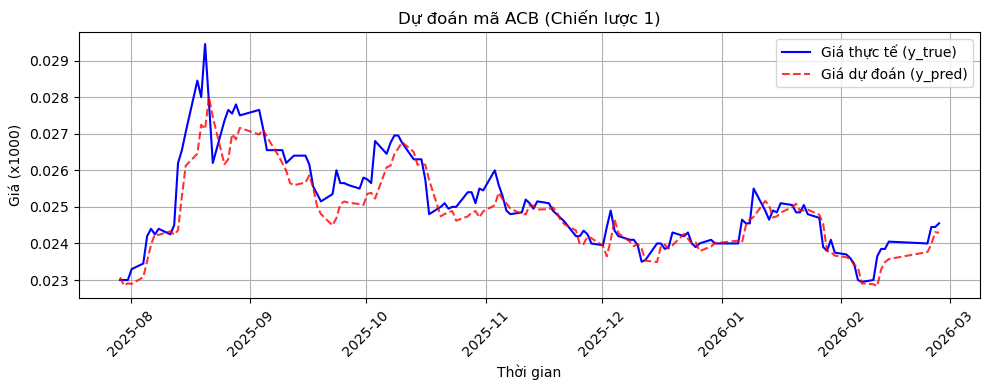

Đang xử lý mã: BCM...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


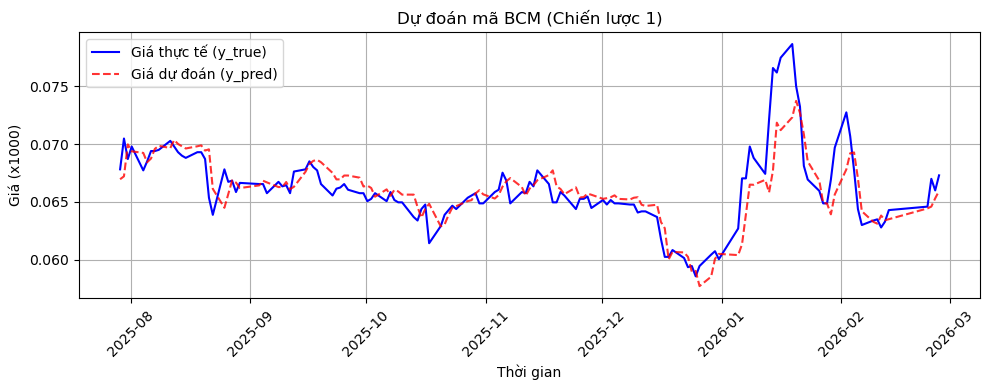

Đang xử lý mã: BID...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


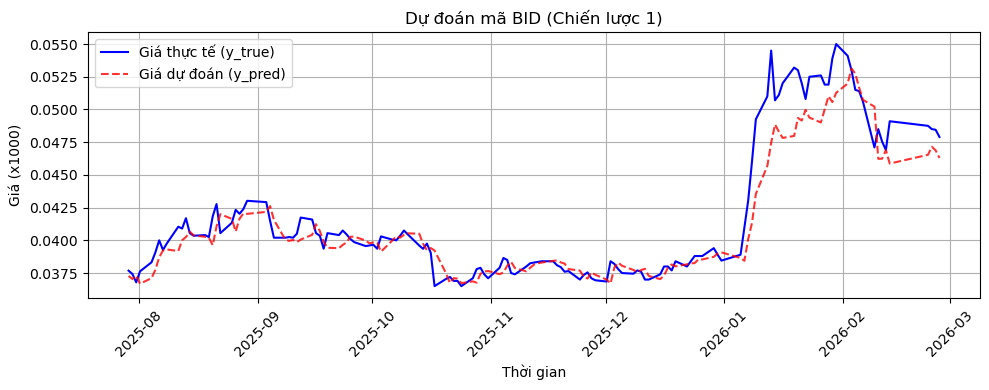

Đang xử lý mã: BVH...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


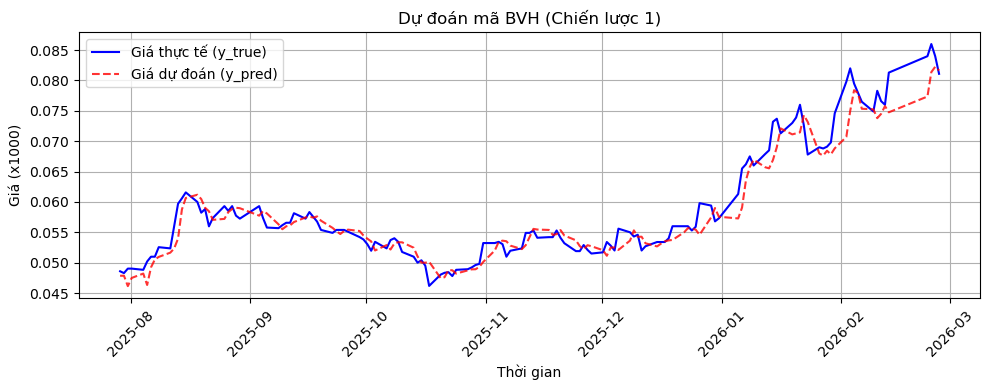

Đang xử lý mã: CTG...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


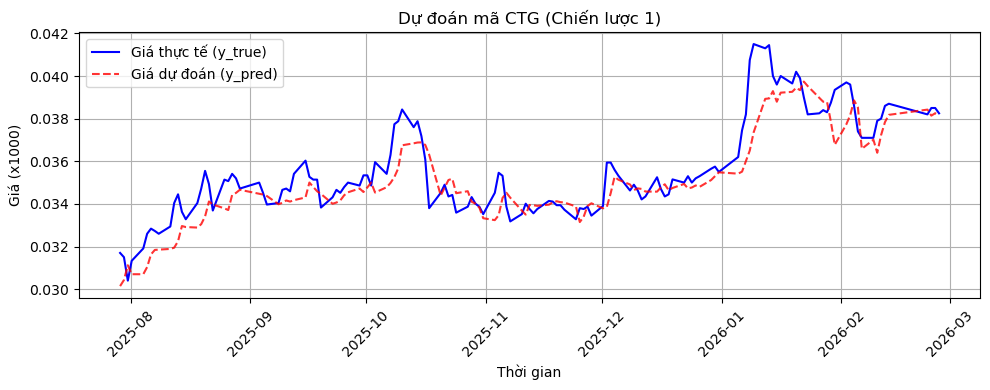

Đang xử lý mã: FPT...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


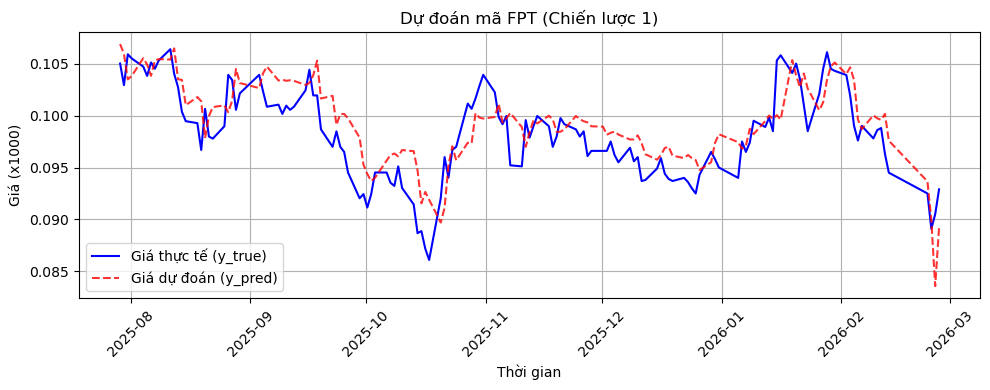

Đang xử lý mã: GAS...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


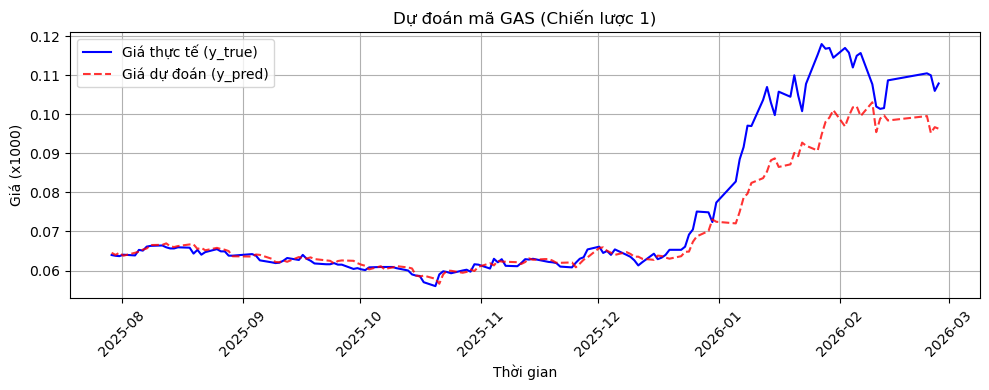

Đang xử lý mã: GVR...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


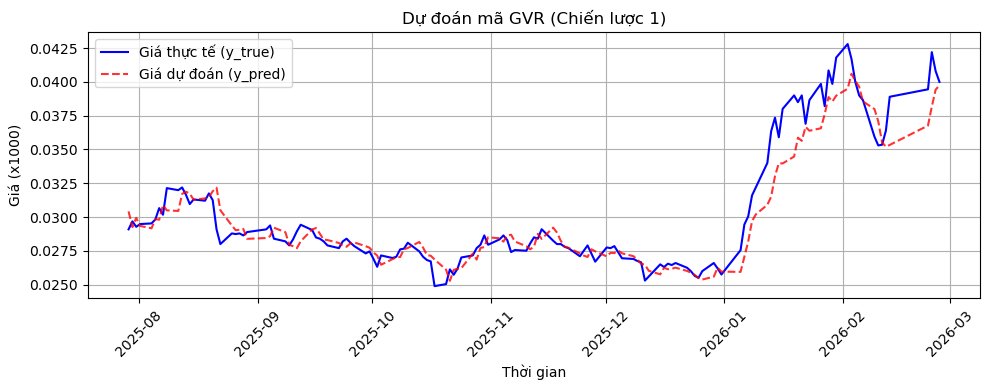

Đang xử lý mã: HDB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


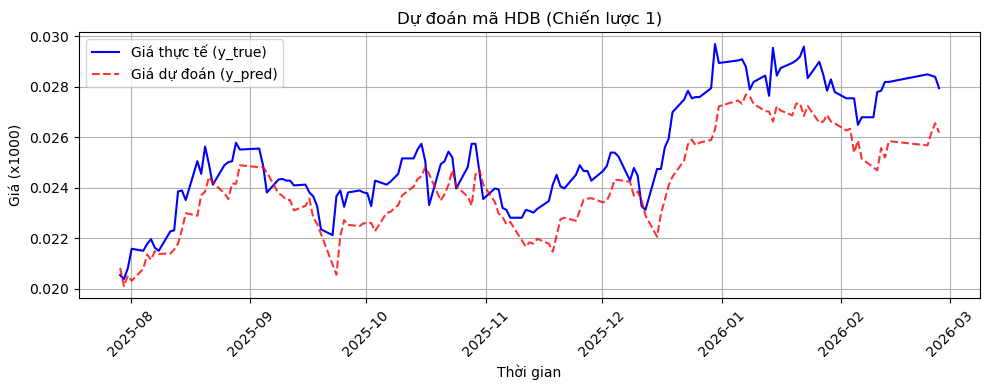

Đang xử lý mã: HPG...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


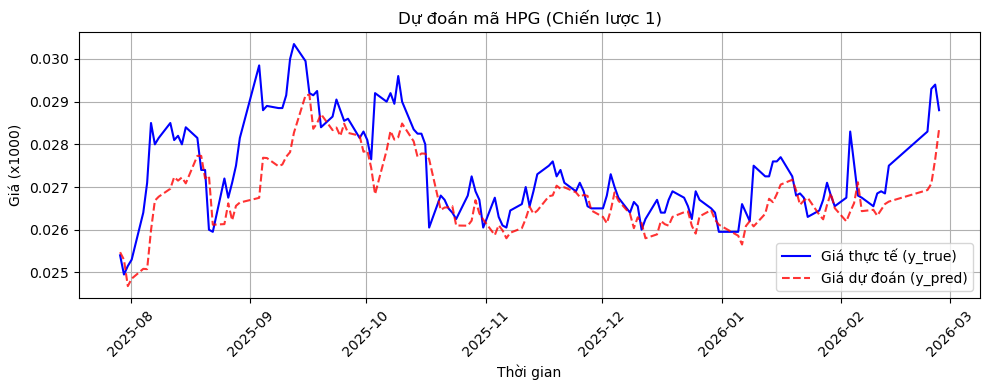

Đang xử lý mã: MBB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


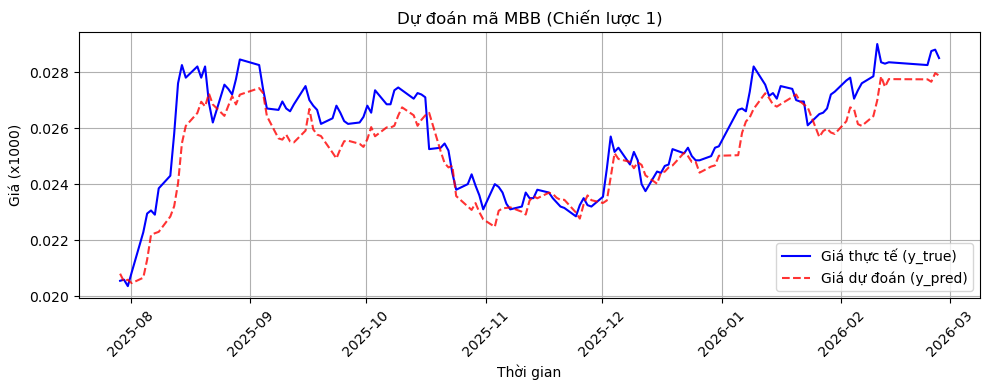

Đang xử lý mã: MSN...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


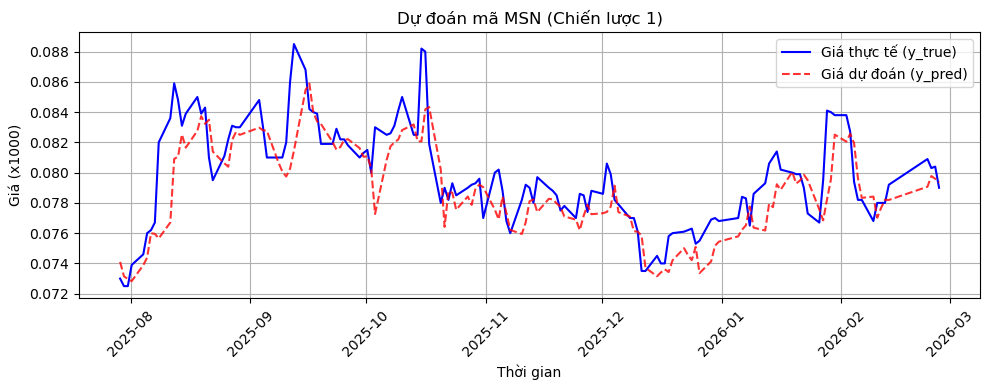

Đang xử lý mã: MWG...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


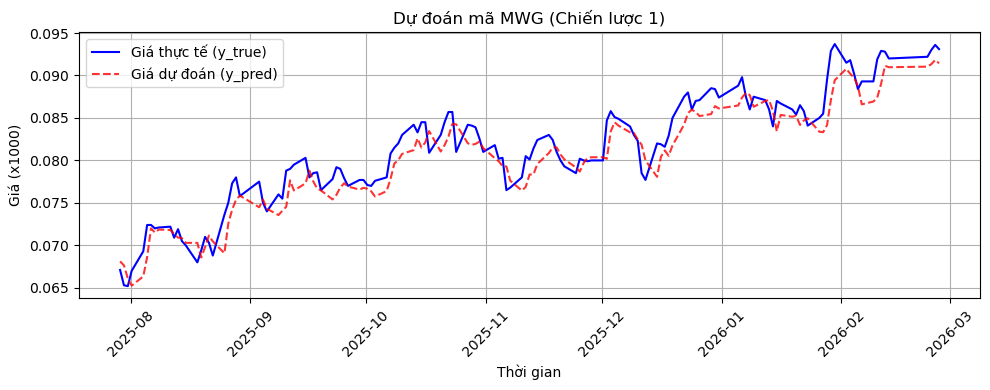

Đang xử lý mã: PLX...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


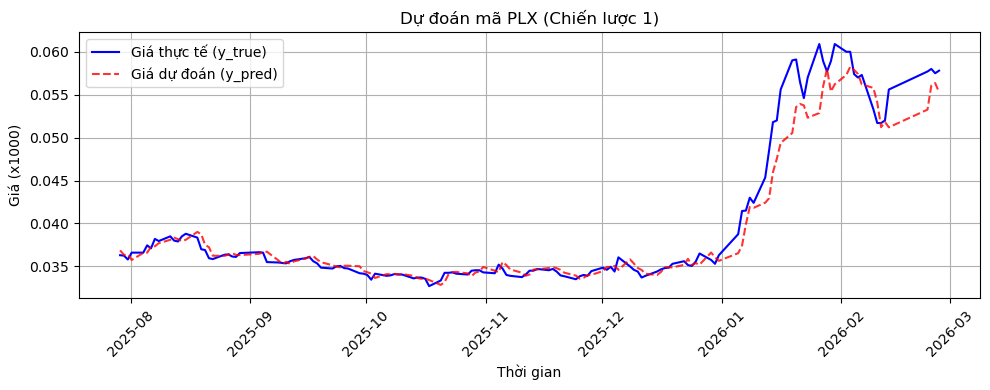

Đang xử lý mã: POW...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


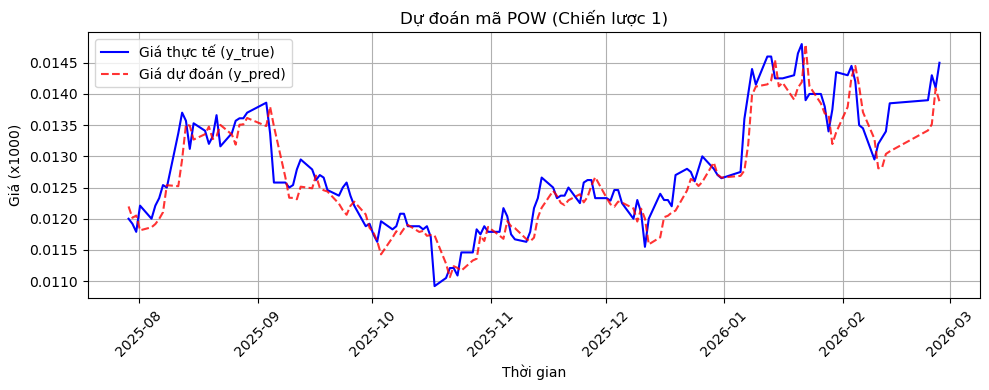

Đang xử lý mã: SAB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


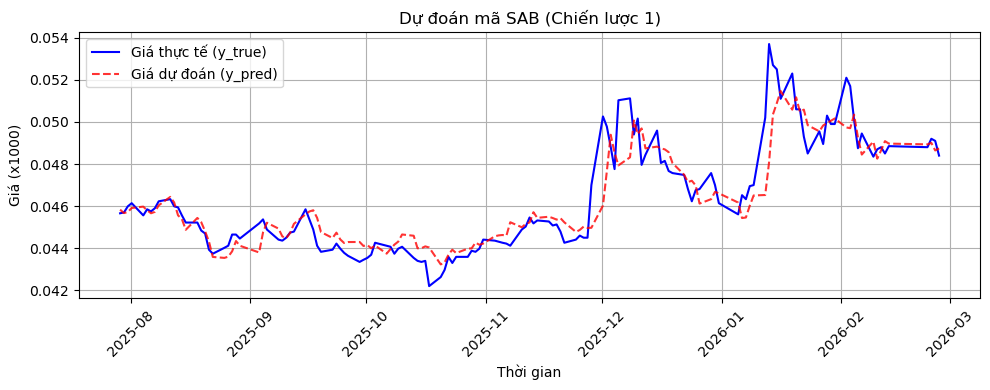

Đang xử lý mã: SHB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


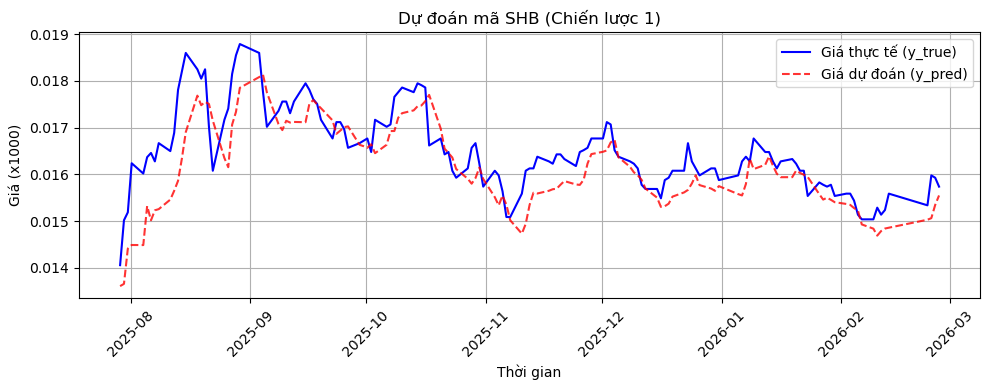

Đang xử lý mã: SSB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


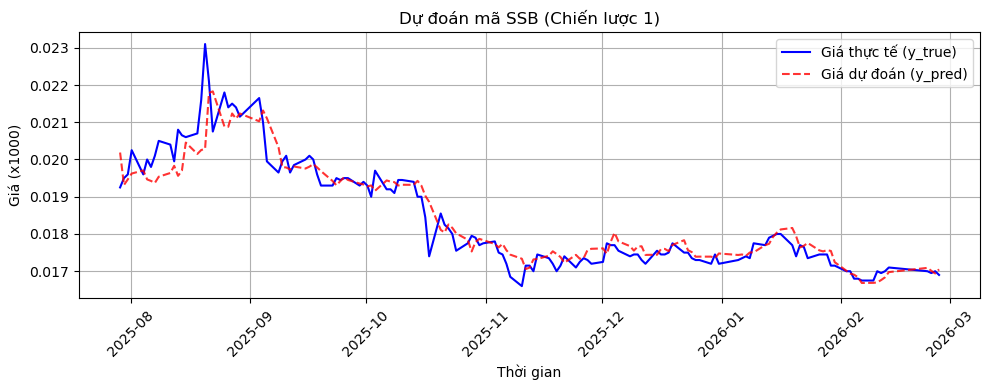

Đang xử lý mã: SSI...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


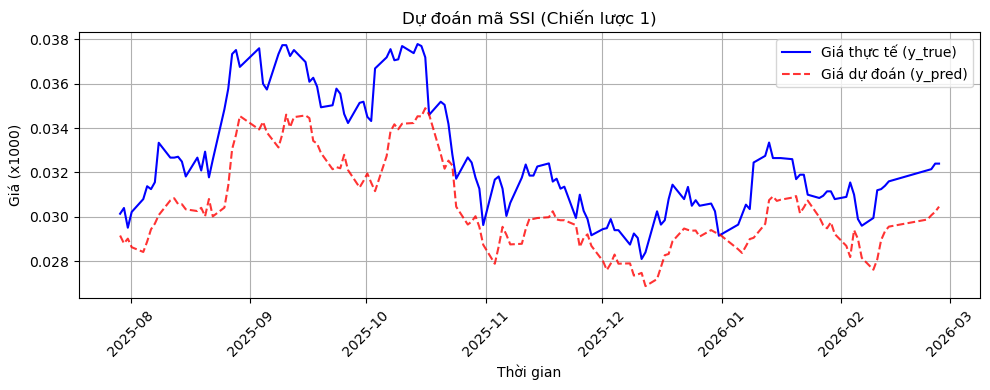

Đang xử lý mã: STB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


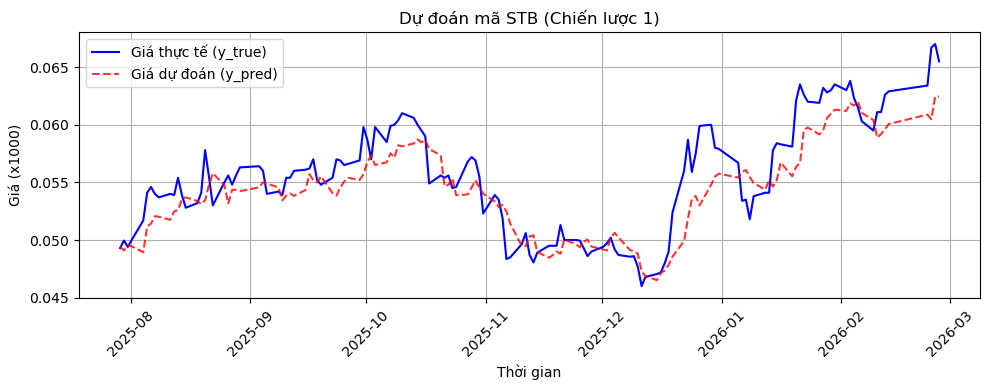

Đang xử lý mã: TCB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


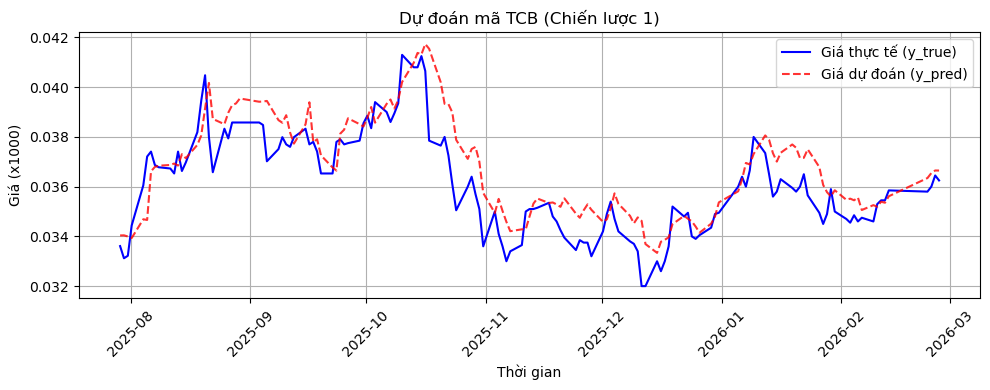

Đang xử lý mã: TPB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


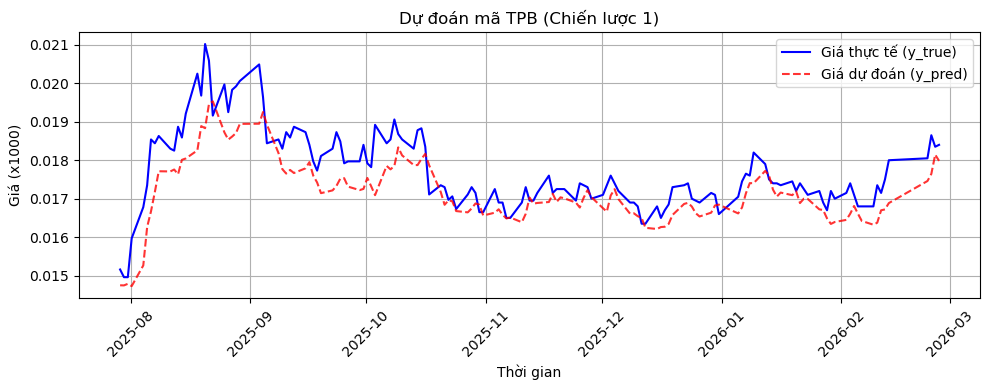

Đang xử lý mã: VCB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


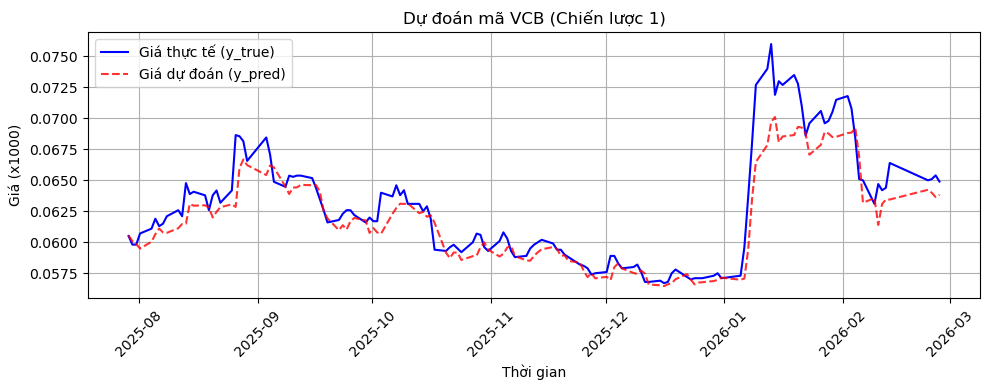

Đang xử lý mã: VHM...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


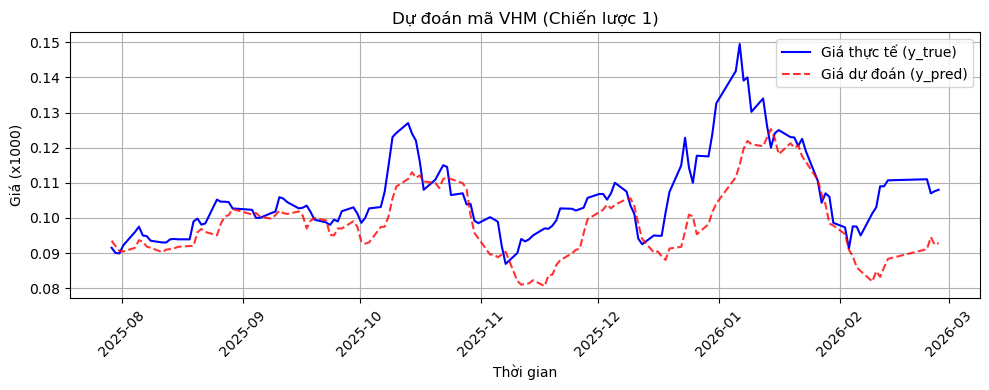

Đang xử lý mã: VIB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


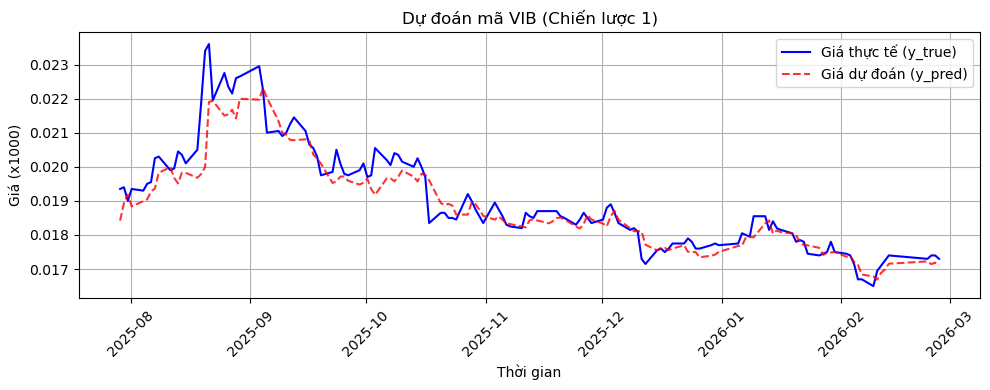

Đang xử lý mã: VIC...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


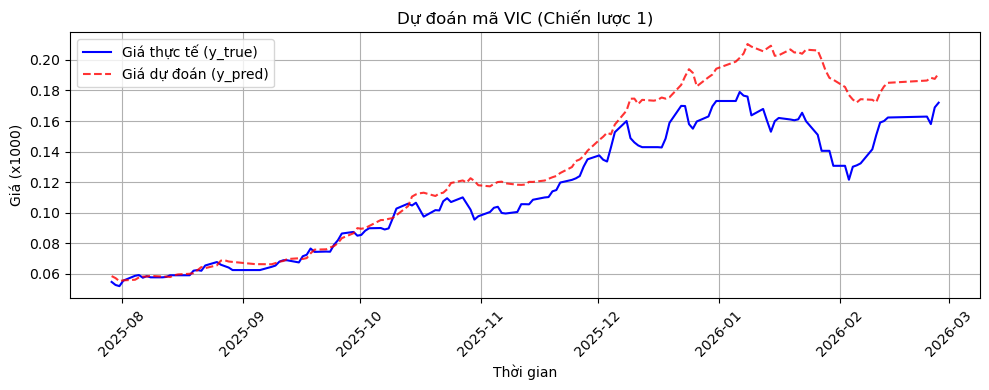

Đang xử lý mã: VJC...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


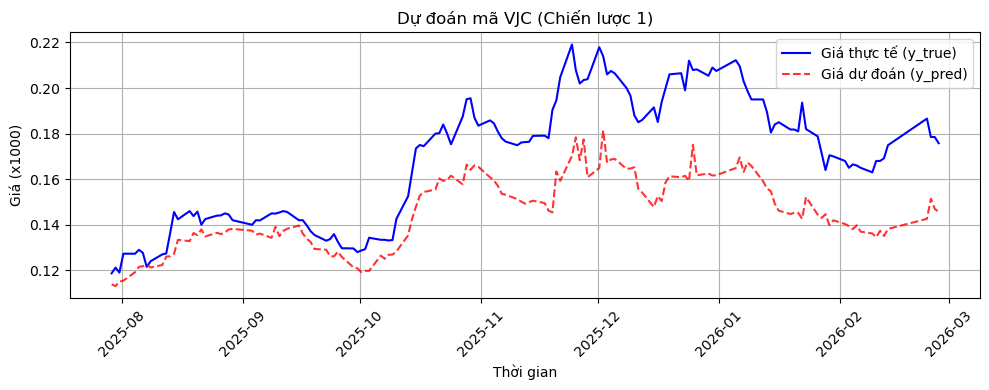

Đang xử lý mã: VNM...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


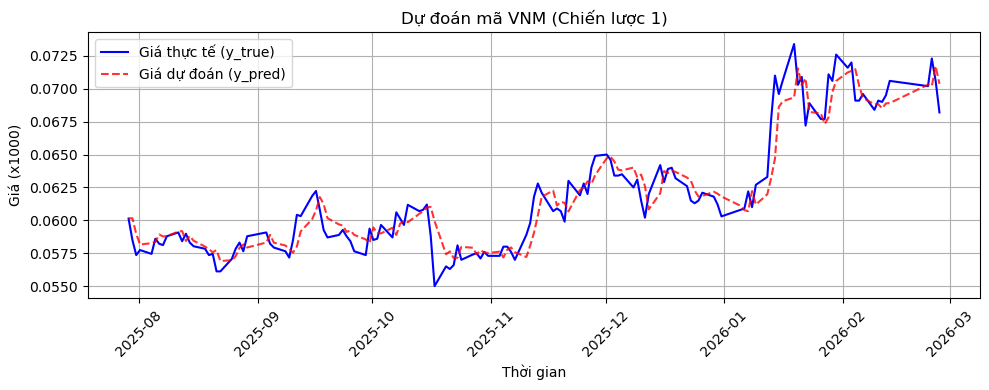

Đang xử lý mã: VPB...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


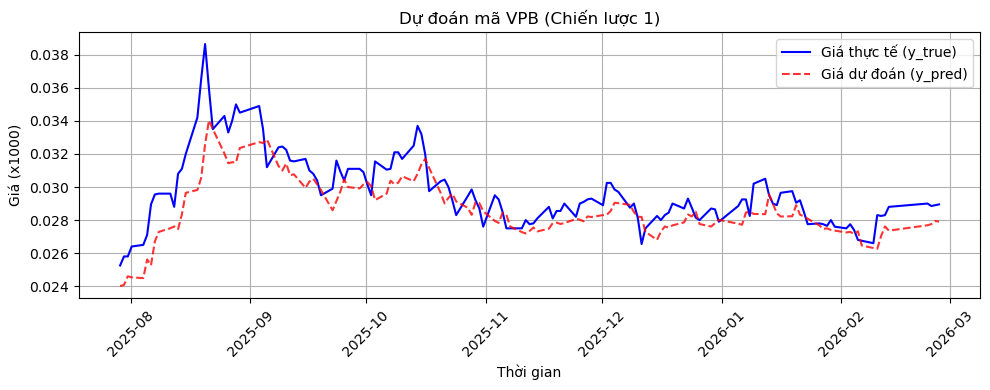

Đang xử lý mã: VRE...


d:\Admin\miniconda3\envs\credit_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


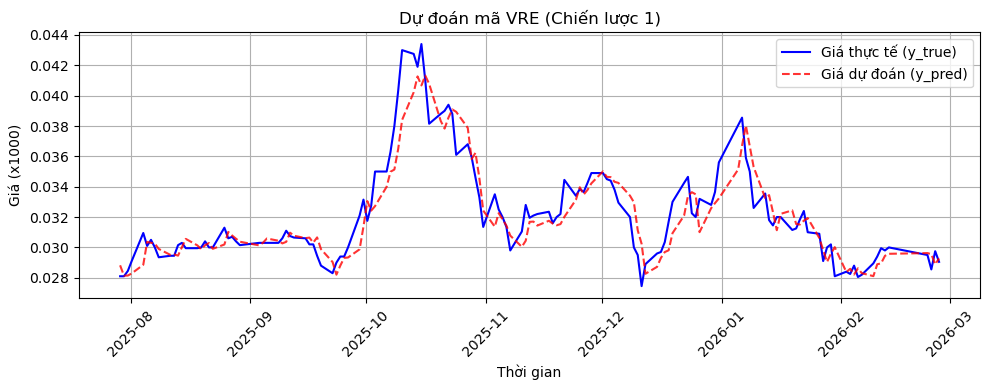

In [5]:
# ==========================================
# 2. VÒNG LẶP XỬ LÝ CHO TỪNG MÃ CỔ PHIẾU
# ==========================================
for ticker in tickers:
    file_path = f"{data_folder}/{ticker}_price_2023_2026.csv"
    
    # Kiểm tra xem file có tồn tại không
    if not os.path.exists(file_path):
        print(f"Không tìm thấy file cho mã {ticker}, bỏ qua...")
        continue
        
    print(f"Đang xử lý mã: {ticker}...")
    
    # --- Đọc và chuẩn hóa dữ liệu ---
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    df.sort_values('time', inplace=True)
    df.set_index('time', inplace=True)
    
    # Chuẩn hóa giá: chia cho 1000
    price_cols = ['open', 'high', 'low', 'close']
    df[price_cols] = df[price_cols] / 1000.0

    # --- Feature Engineering (Chiến lược 1) ---
    # 1. RSI
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # 2. Ichimoku 65
    period_65_high = df['high'].rolling(window=65).max()
    period_65_low = df['low'].rolling(window=65).min()
    df['Ichimoku_Base_65'] = (period_65_high + period_65_low) / 2

    # 3. SAR
    df['SAR'] = calculate_sar(df['high'].values, df['low'].values, df['close'].values)

    # 4. Bollinger Bands (N=14, mult=2)
    df['BB_Mid'] = df['close'].rolling(window=14).mean()
    df['BB_Std'] = df['close'].rolling(window=14).std()
    df['BB_Upper_2'] = df['BB_Mid'] + (2 * df['BB_Std'])
    df['BB_Lower_2'] = df['BB_Mid'] - (2 * df['BB_Std'])

    df.dropna(inplace=True)

    # --- Chuẩn bị Input/Output ---
    features = ['open', 'close', 'high', 'low', 'volume', 'RSI', 'Ichimoku_Base_65', 'SAR', 'BB_Upper_2', 'BB_Lower_2']
    X = df[features].copy()
    y = df[['close']].shift(-1)
    
    data = pd.concat([X, y.rename(columns={'close': 'target_close'})], axis=1)
    data.dropna(inplace=True)

    X_clean = data[features].values
    y_clean = data[['target_close']].values

    # --- Scale & Reshape ---
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    X_scaled = scaler_X.fit_transform(X_clean)
    y_scaled = scaler_y.fit_transform(y_clean)
    X_reshaped = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

    # --- Chia Train/Test (80/20) ---
    train_size = int(len(X_reshaped) * 0.8)
    X_train, X_test = X_reshaped[:train_size], X_reshaped[train_size:]
    y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]
    test_dates = data.index[train_size:]

    # --- Build & Train Model ---
    model = Sequential()
    model.add(SimpleRNN(units=64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    # Chỉnh verbose=0 để không bị in ra quá nhiều dòng log làm tràn màn hình
    model.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

    # --- Predict & Evaluate ---
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Lưu kết quả
    results_list.append({
        'Ticker': ticker,
        'MSE': mse,
        'MAE': mae,
        'R2_Score': r2
    })

    # --- Vẽ biểu đồ ---
    plt.figure(figsize=(10, 4))
    plt.plot(test_dates, y_true, color='blue', label='Giá thực tế (y_true)')
    plt.plot(test_dates, y_pred, color='red', linestyle='dashed', alpha=0.8, label='Giá dự đoán (y_pred)')
    plt.title(f'Dự đoán mã {ticker} (Chiến lược 1)')
    plt.xlabel('Thời gian')
    plt.ylabel('Giá (x1000)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # Đóng plot để giải phóng bộ nhớ trước khi lặp qua mã tiếp theo
    plt.close()

In [6]:
# ==========================================
# 3. TỔNG HỢP VÀ HIỂN THỊ BẢNG KẾT QUẢ
# ==========================================
print("\n" + "="*60)
print(" HOÀN TẤT HUẤN LUYỆN 30 MÃ VN30 ")
print("="*60)

# Tạo DataFrame từ list kết quả
summary_df = pd.DataFrame(results_list)

# Làm tròn các chỉ số để hiển thị cho đẹp
summary_df['MSE'] = summary_df['MSE'].round(4)
summary_df['MAE'] = summary_df['MAE'].round(4)
summary_df['R2_Score'] = summary_df['R2_Score'].round(4)

# Sắp xếp bảng theo MSE từ thấp lên cao để xem mã nào dự đoán tốt nhất
summary_df.sort_values(by='MSE', ascending=True, inplace=True)
summary_df.reset_index(drop=True, inplace=True)

# Hiển thị bảng tổng hợp
display(summary_df)
summary_df.to_csv('VN30_Evaluation_Results.csv', index=False)
print("\nĐã lưu kết quả ra file 'VN30_Evaluation_Results.csv'.")


 HOÀN TẤT HUẤN LUYỆN 30 MÃ VN30 


,Ticker,MSE,MAE,R2_Score
0,ACB,0.0000,0.0004,0.8070
1,BCM,0.0000,0.0012,0.6803
2,BID,0.0000,0.0010,0.8983
3,BVH,0.0000,0.0016,0.9389
4,CTG,0.0000,0.0008,0.7594
5,FPT,0.0000,0.0023,0.6158
6,GVR,0.0000,0.0009,0.9088
7,HDB,0.0000,0.0013,0.5450
8,MWG,0.0000,0.0017,0.8941
9,HPG,0.0000,0.0006,0.3816



Đã lưu kết quả ra file 'VN30_Evaluation_Results.csv'.
